In [ ]:
# Cell 1: Install dependencies
!pip install -q librosa joblib

In [ ]:
# Cell 2: Download and extract RAVDESS dataset
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!rm -rf ravdess-emotional-speech-audio
!mkdir ravdess-emotional-speech-audio
!unzip -o -q ravdess-emotional-speech-audio.zip -d ravdess-emotional-speech-audio
print(" RAVDESS dataset is ready")

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:03<00:00, 130MB/s]

 RAVDESS dataset is ready


In [ ]:
# Cell 3: Download and extract TESS dataset

!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess
!rm -rf tess-data
!mkdir tess-data
!unzip -o -q toronto-emotional-speech-set-tess.zip -d tess-data
print(" TESS dataset is ready")

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 428M/428M [00:04<00:00, 101MB/s] 

 TESS dataset is ready


In [ ]:
# Cell 4: Import libraries

import os
import joblib
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Activation,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

print(" Libraries imported successfully")

 Libraries imported successfully


In [ ]:
# Cell 5: Define emotion mappings and helper functions
emotions = {
    0: 'neutral', 1: 'calm', 2: 'happy', 3: 'sad',
    4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised'
}

tess_emotion_map = {
    'neutral': 0, 'calm': 1, 'happy': 2, 'sad': 3,
    'angry': 4, 'fear': 5, 'disgust': 6, 'ps': 7
}

def add_noise(y):
    return y + np.random.normal(0, 0.005, y.shape)
def time_stretch(y):
    return librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
def pitch_shift(y, sr):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.randint(-3, 3))
def extract_mfcc(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=60)
    return np.mean(mfccs.T, axis=0)
print(" Emotion mappings and helper functions defined successfully")

 Emotion mappings and helper functions defined successfully


In [ ]:
# Cell 6: Load and augment RAVDESS data
def load_ravdess(data_path):
    data, labels = [], []
    for dirname, _, filenames in os.walk(data_path):
        for filename in filenames:
            if not filename.endswith('.wav'):
                continue
            try:
                label = int(filename[7:8]) - 1
                path = os.path.join(dirname, filename)
                y, sr = librosa.load(path, duration=3, offset=0.5)
                data.append(extract_mfcc(y, sr));               labels.append(label)
                data.append(extract_mfcc(add_noise(y), sr));    labels.append(label)
                data.append(extract_mfcc(time_stretch(y), sr)); labels.append(label)
                data.append(extract_mfcc(pitch_shift(y, sr), sr)); labels.append(label)
            except Exception as e:
              print(f"Skipped {filename}: {e}")
    return data, labels
print(" Loading RAVDESS dataset...")
r_data, r_labels = load_ravdess('./ravdess-emotional-speech-audio/')

#Try alternative path if dataset is empty
if len(r_data) == 0:
    alt_path = './ravdess-emotional-speech-audio/audio_speech_actors_01-24/'
    if os.path.exists(alt_path):
        print(f" Trying alternative path: {alt_path}")
        r_data, r_labels = load_ravdess(alt_path)
print(f" RAVDESS loaded successfully: {len(r_data)} samples")

 Loading RAVDESS dataset...
 RAVDESS loaded successfully: 11520 samples


In [ ]:
# Cell 7: Load and augment TESS data

def load_tess(data_path):
    data, labels = [], []
    for dirname, _, filenames in os.walk(data_path):
        folder_name = os.path.basename(dirname).lower()
        # Map folder name to emotion label
        emotion_key = next((k for k in tess_emotion_map if k in folder_name), None)
        if emotion_key is None:
            continue
        label = tess_emotion_map[emotion_key]

        for filename in filenames:
            if not filename.endswith('.wav'):
                continue

            try:
                path = os.path.join(dirname, filename)

                # Load original audio (first 3 seconds)
                y, sr = librosa.load(path, duration=3, offset=0.5)

                # Original
                data.append(extract_mfcc(y, sr))
                labels.append(label)

                # Augmented versions
                data.append(extract_mfcc(add_noise(y), sr))
                labels.append(label)

                data.append(extract_mfcc(time_stretch(y), sr))
                labels.append(label)

                data.append(extract_mfcc(pitch_shift(y, sr), sr))
                labels.append(label)
            except Exception as e:
                print(f'  Skipping {filename}: {e}')
    return data, labels
print(' Loading TESS dataset...')
t_data, t_labels = load_tess('./tess-data/')
print(f' TESS loaded: {len(t_data)} samples')

 Loading TESS dataset...
 TESS loaded: 19200 samples


In [ ]:
# Cell 8: Merge datasets, normalize features, and split data

# Merge RAVDESS and TESS data
all_data   = r_data + t_data
all_labels = r_labels + t_labels
print(f' Total samples: {len(all_data)}')
if len(all_data) == 0:
    raise ValueError(' No data found. Please check the RAVDESS and TESS dataset paths.')
# Convert to numpy arrays
X = np.asarray(all_data)
y = to_categorical(np.array(all_labels))
# Feature scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=9
)
print(f'Training samples : {x_train.shape[0]}')
print(f'Testing samples  : {x_test.shape[0]}')

 Total samples: 30720
Training samples : 24576
Testing samples  : 6144


In [ ]:
# Cell 9: Build Sequential Neural Network model
def create_optimized_model():
    model = Sequential([
        Dense(256, input_shape=(60,)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),
        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.3),
        Dense(8, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model
model = create_optimized_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,080 (199.53 KB)

 Trainable params: 50,312 (196.53 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Cell 10: Train the model with Early Stopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
print(' Starting model training...')
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=True
)
print(' Training completed!')

 Starting model training...
Epoch 1/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6739 - loss: 0.9130 - val_accuracy: 0.7879 - val_loss: 0.5976
Epoch 2/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7488 - loss: 0.6902 - val_accuracy: 0.8136 - val_loss: 0.5164
Epoch 3/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7727 - loss: 0.6236 - val_accuracy: 0.8354 - val_loss: 0.4801
Epoch 4/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7858 - loss: 0.5885 - val_accuracy: 0.8421 - val_loss: 0.4463
Epoch 5/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7969 - loss: 0.5532 - val_accuracy: 0.8556 - val_loss: 0.4237
Epoch 6/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8038 - loss: 0.5341 - val_accuracy: 0.8587 - val_loss: 0.4033
Epoch 7/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8116 - loss: 0.5165 - val_accuracy: 0.8670 - val_loss: 0.3924
Epoch 8/80
768/768 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8175 - los

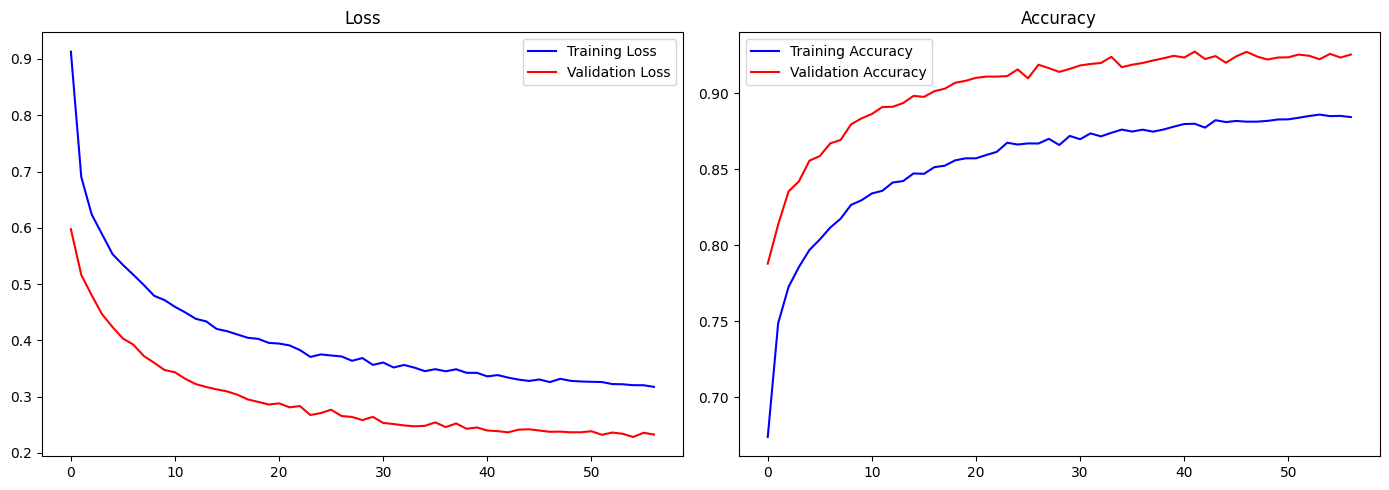

In [ ]:
# Cell 11: Visualize training results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     'b', label='Training Loss')
axes[0].plot(history.history['val_loss'], 'r', label='Validation Loss')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     'b', label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], 'r', label='Validation Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12: Evaluate final model accuracy
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f' Final Test Accuracy: {accuracy * 100:.2f}%')
print(f' Final Test Loss:    {loss:.4f}')

 Final Test Accuracy: 92.74%
 Final Test Loss:    0.2388


In [ ]:
# Cell 13: Save model and scaler

model.save('emotion_model.h5')
joblib.dump(scaler, 'scaler.pkl')
print(' Model saved as: emotion_model.h5')
print(' Scaler saved as: scaler.pkl')
print(' Model and scaler saved successfully!')

 Model saved as: emotion_model.h5
 Scaler saved as: scaler.pkl
 Model and scaler saved successfully!


In [ ]:
# Cell 14: Prediction function for new audio files

def predict_emotion(file_path):
    """
    Predict emotion from a new audio file.
    """
    # Load and extract features
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    features = extract_mfcc(y, sr).reshape(1, -1)
    # Scale features
    features_scaled = scaler.transform(features)
    # Make prediction
    prediction = model.predict(features_scaled, verbose=0)
    idx = np.argmax(prediction)
    emotion = emotions[idx]
    confidence = prediction[0][idx] * 100
    # Display results
    print(f' Predicted Emotion : {emotion.upper()}')
    print(f' Confidence        : {confidence:.2f}%')
    print('\nProbability Distribution:')
    for i, prob in enumerate(prediction[0]):
        bar = '' * int(prob * 30)
        print(f'  {emotions[i]:12s} {bar} {prob*100:.1f}%')
    return emotion, confidence
# Example usage:
# predict_emotion('test.wav')
print(' Prediction function ready! Use predict_emotion("your_audio.wav")')

 Prediction function ready! Use predict_emotion("your_audio.wav")
